In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from pyquasoare import approx, models

# Structure of the GR2M rainfall-runoff model
The [GR2M](https://webgr.inrae.fr/eng/tools/hydrological-models/monthly-hydrological-model-gr2m) is a monthly rainfall-runoff model that is used to simulate rainfall-runoff relationship at the catchment scale. It is characterised by a very parsomonious structure that only requires the definition of two parameters defined below. The model possesses two internal stores as shown in the image below. 

![GR2M Model](gr2m_model.png)

The first store is named "production store" and is characterised by the following ODE following [Mouelhi et al.](https://www.sciencedirect.com/science/article/pii/S0022169405003033):
$$
\frac{dx}{dt} = \frac{P}{X_1} (1 - x^2) - \frac{E_0}{X_1}\ x\ (2 - x) -\frac{1}{\Delta} x^{4/3}
$$
with $x = S/X_1$ \[-\] the store level, $X_1$ \[mm\] the store capacity (the first GR2M parameter), $P$ the monthly rainfall \[mm/mth\], $E_0$ \[mm/mth\] the potential evapotranspiration and $\Delta$ \[mth\] is the timestep duration (=1). The effective rainfall generated by this store is defined as follows:
$$
    P_{eff} = P\ x^2 + \frac{X_1}{\Delta}\ x^{4/3}
$$

The second store is named "routing store" and is characterised by the following equation:
$$
\frac{dy}{dt} = \frac{P_{eff}}{X_3} + \frac{X_2}{X_3}\ y - \frac{1}{\Delta} y^2
$$
where $y = R / X_3$ \[-\] the store level, $X_3$ \[mm\] is the store capacity set to 60mm, $X_2$ \[mm/mth\] is the rate of inter-catchment exchange (see [Mouelhi et al.](https://www.sciencedirect.com/science/article/pii/S0022169405003033)). The simulated discharge 

# Resolution of the model using the QuaSoARe solver
The flux functions from the two reservoirs are first approximated by piecewise-quadratic function via the [approx.quad_coefficient_matrix](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/approx.py#L267) function in the pyquasoare package. These functions are defined up to a multiplicative constant that will be defined later as "flux scalings".

The production store requires the definition of three flux functions: 
* $f_1(x) = 1 - x^2$
* $f_2(x) = - x\ (2 - x)$
* $f_3(x) = - x^{4/3}$

We approximate these functions using 10 nodes between $x=0$ and $x=1$ as follows:

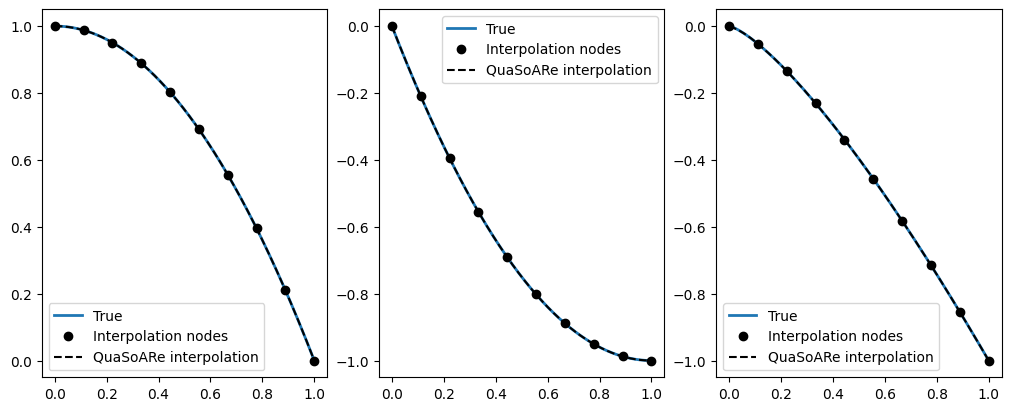

In [2]:
def f1(x):
    return 1 - x**2
    
def f2(x):
    return - x * (2 - x)

def f3(x):
    return -x**(4./3.)

nalphas = 10
alphas = np.linspace(0, 1, nalphas)
prod_coefs = approx.quad_coefficient_matrix([f1, f2, f3], alphas)

xx = np.linspace(0, 1, 500)
fint = approx.quad_fun_from_matrix(alphas, prod_coefs, xx)
fig, axs = plt.subplots(ncols=3, figsize=(10, 4), layout="constrained")
for ifx in range(3):
    ax = axs[ifx]
    fx = [f1, f2, f3][ifx]
    ax.plot(xx, fx(xx), label="True", lw=2)
    ax.plot(alphas, fx(alphas), "ko", label="Interpolation nodes")
    ax.plot(xx, fint[:, ifx], "k--", label="QuaSoARe interpolation")
    ax.legend()


We now repeat the process for the flux functions corresponding to the routing store:
* $g_1(x) = 1$
* $g_2(x) = x$
* $g_3(x) = - x^2$


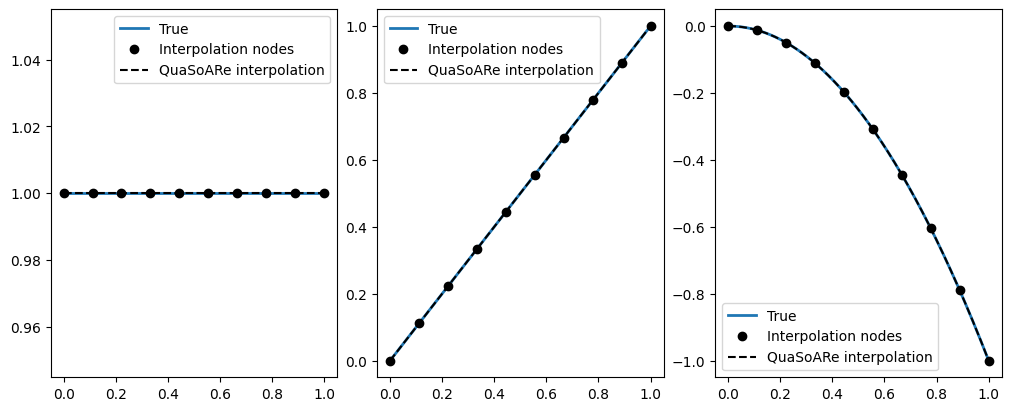

In [3]:
def g1(x):
    return np.ones_like(x)
    
def g2(x):
    return x

def g3(x):
    return -x**2

alphas = np.linspace(0, 1, 10)
route_coefs = approx.quad_coefficient_matrix([g1, g2, g3], alphas)

xx = np.linspace(0, 1, 500)
fint = approx.quad_fun_from_matrix(alphas, route_coefs, xx)
fig, axs = plt.subplots(ncols=3, figsize=(10, 4), layout="constrained")
for ifx in range(3):
    ax = axs[ifx]
    fx = [g1, g2, g3][ifx]
    ax.plot(xx, fx(xx), label="True", lw=2)
    ax.plot(alphas, fx(alphas), "ko", label="Interpolation nodes")
    ax.plot(xx, fint[:, ifx], "k--", label="QuaSoARe interpolation")
    ax.legend()


# Run the solver with given inputs
Once the interpolation of the flux function is completed, we can run the QuaSoARe solver with a series of inputs. 
As indicated above, the flux functions were defined up to a multiplicative constant. These constant can be defined for each timestep and are named "scalings". Running the QuaSoARe solver using timeseries inputs is done via the ["models.quad_model"](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/models.py#L14) function. 

The three flux scalings for the production stores are as follows:
* $\eta_1 = P / X_1$ (corresponding to flux function $f_1$)
* $\eta_2 = E_0 / X_1$ (corresponding to flux function $f_2$)
* $\eta_3 = 1 / \Delta$ (corresponding to flux function $f_3$)

For the routing store, we have:
* $\mu_1 = P_{eff} / X_3$ (corresponding to flux function $g_1$)
* $\mu_2 = X_2 /X_3 $ (corresponding to flux function $g_2$)
* $\mu_3 = 1 / \Delta$ (corresponding to flux function $g_3$)


In [4]:
# Timestep (one month)
Delta = 1

# Random rainfall and PET timeseries
nval = 100
P = 10 * np.exp(np.random.uniform(-4, 4, size=nval))
time = np.arange(nval)
E0 = 200 * (1 + np.cos(time * 2 * math.pi / 12)) / 2
print(f"Mean annual P   = {P.mean() * 12:0.0f}")
print(f"Mean annual PET = {E0.mean() * 12:0.0f}")
    
# We run the solver for a given parameters
X1 = 400
X2 = -10
X3 = 60
x0 = 0.5

# Define flux scalings
prod_scalings = np.ones((nval, 3))
prod_scalings[:, 0] = P / X1
prod_scalings[:, 1] = E0 / X1
prod_scalings[:, 2] = 1 / Delta

route_scalings = np.ones((nval, 3))
# .. first scaling is defined by Peff, which needs the solution of the production store
route_scalings[:, 1] = X2 / X3
route_scalings[:, 2] = 1 / Delta

# Solve production store
_, prod_x, prod_fluxes = models.quad_model(alphas, prod_scalings, prod_coefs, x0, Delta)
Peff = (P - prod_fluxes[:, 0] * X1) - prod_fluxes[:, 2] * X1
AET = -prod_fluxes[:, 1] * X1

# Solve routing store
route_scalings[:, 0] = Peff / X1
_, route_x, route_fluxes = models.quad_model(alphas, route_scalings, route_coefs, x0, Delta)
Q = -route_fluxes[:, 2] * X3
IGF = route_fluxes[:, 1] * X3

Mean annual P   = 766
Mean annual PET = 1228


# Results for the production store

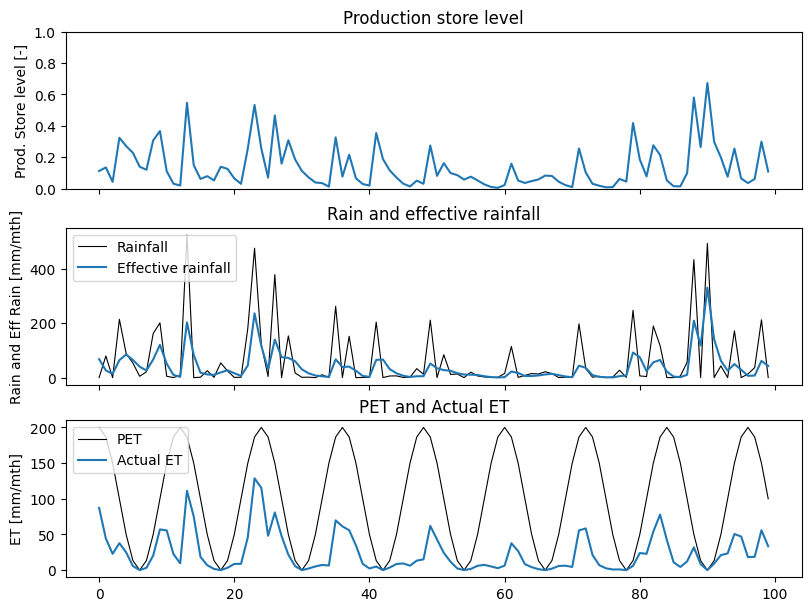

In [5]:
fig, axs = plt.subplots(nrows=3, figsize=(8, 6), layout="constrained",
                        sharex=True)
ax = axs[0]
ax.plot(time, prod_x)
ax.set(ylabel="Prod. Store level [-]",
       title="Production store level",
       ylim=[0, 1])

ax = axs[1]
ax.plot(time, P, "k-", lw=0.8, label="Rainfall")
ax.plot(time, Peff, label="Effective rainfall")
ax.set(title="Rain and effective rainfall",
       ylabel="Rain and Eff Rain [mm/mth]")
ax.legend(loc=2)

ax = axs[2]
ax.plot(time, E0, "k-", lw=0.8, label="PET")
ax.plot(time, AET, label="Actual ET")
ax.set(title="PET and Actual ET",
       ylabel="ET [mm/mth]")
ax.legend(loc=2)

# Results for the routing store

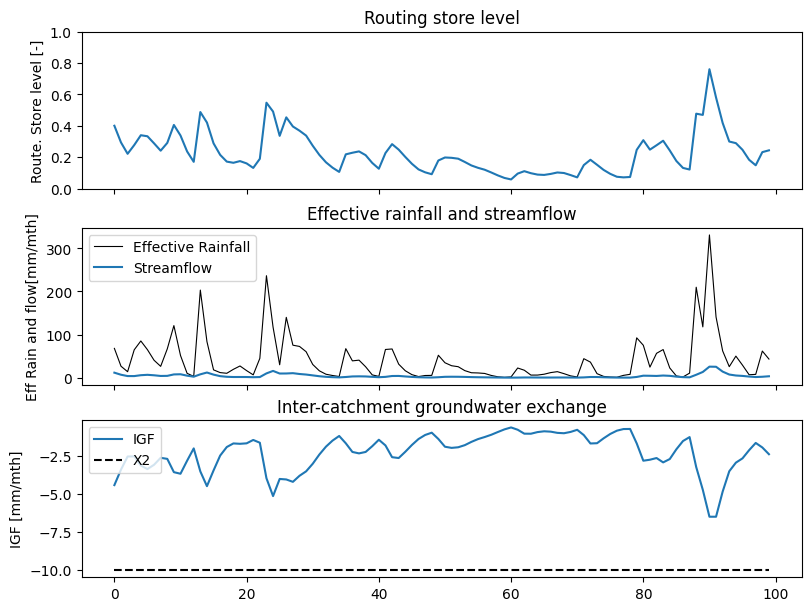

In [6]:
fig, axs = plt.subplots(nrows=3, figsize=(8, 6), layout="constrained",
                        sharex=True)
ax = axs[0]
ax.plot(time, route_x)
ax.set(ylabel="Route. Store level [-]",
       title="Routing store level",
       ylim=[0, 1])

ax = axs[1]
ax.plot(time, Peff, "k-", lw=0.8, label="Effective Rainfall")
ax.plot(time, Q, label="Streamflow")
ax.set(title="Effective rainfall and streamflow",
       ylabel="Eff Rain and flow[mm/mth]")
ax.legend(loc=2)

ax = axs[2]
ax.plot(time, IGF, label="IGF")
ax.plot(time[[0, -1]], [X2] * 2, "k--", label="X2")
ax.set(title="Inter-catchment groundwater exchange",
       ylabel="IGF [mm/mth]")
ax.legend(loc=2)

# Testing different parameters
We can easily compare the solution obtained with different values for parameters $X_1$ (production store capacity) and $X_2$ (IGF coefficient).

In [8]:
def solve(X1, X2, X3=60.):  
    # 1. Define flux scalings
    prod_scalings = np.ones((nval, 3))
    prod_scalings[:, 0] = P / X1
    prod_scalings[:, 1] = E0 / X1
    prod_scalings[:, 2] = 1 / Delta

    route_scalings = np.ones((nval, 3))
    route_scalings[:, 1] = X2 / X3
    route_scalings[:, 2] = 1 / Delta

    # 2. Solve production store
    _, prod_x, prod_fluxes = models.quad_model(alphas, prod_scalings, prod_coefs, x0, Delta)
    Peff = (P - prod_fluxes[:, 0] * X1) - prod_fluxes[:, 2] * X1
    AET = -prod_fluxes[:, 1] * X1

    # 3. Solve routing store
    route_scalings[:, 0] = Peff / X1
    _, route_x, route_fluxes = models.quad_model(alphas, route_scalings, route_coefs, x0, Delta)
    Q = -route_fluxes[:, 2] * X3
    IGF = route_fluxes[:, 1] * X3
    return Peff, AET, Q, IGF
    

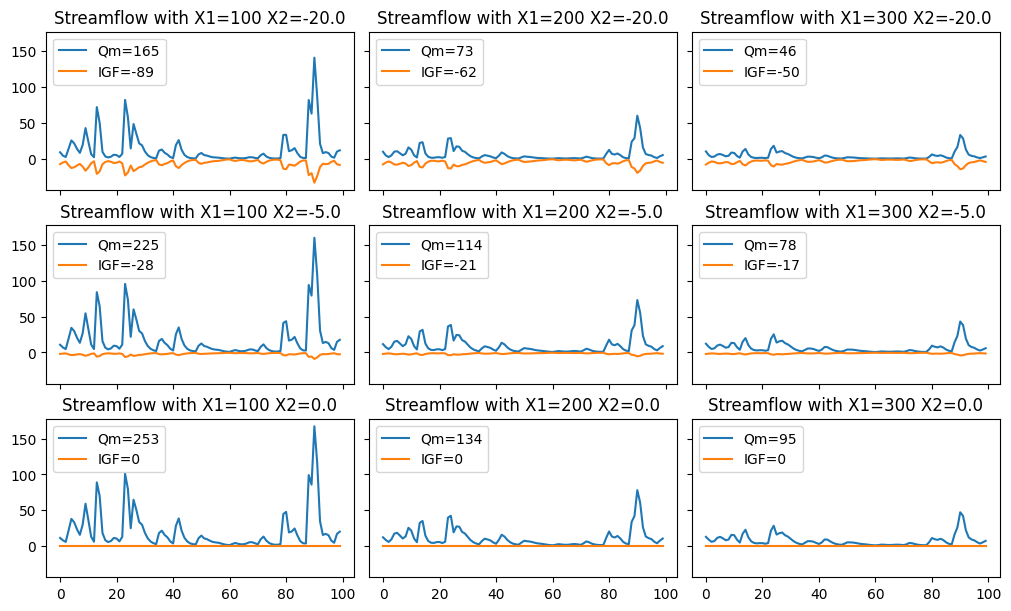

In [9]:
X1s = [100, 200, 300]
X2s = [-20, -5, 0]
mosaic = [[f"{v1}/{v2}" for v1 in X1s] for v2 in X2s]
fig = plt.figure(figsize=(10, 6), layout="constrained")
axs = fig.subplot_mosaic(mosaic, sharex=True, sharey=True)

for aname, ax in axs.items():
    X1, X2 = [float(v) for v in aname.split("/")]
    Peff, AET, Q, IGF = solve(X1, X2)
    ax.plot(time, Q, label=f"Qm={Q.mean() * 12:0.0f}")
    ax.plot(time, IGF, label=f"IGF={IGF.mean() * 12:0.0f}")
    ax.set(title=f"Streamflow with X1={X1:0.0f} X2={X2:0.1f}")
    ax.legend(loc=2)